# Volatility Forecasting – SPY with GARCH(1,1)  
Small quant research demonstration project

```
# This is formatted as code
```



# SPY Volatility Forecasting with GARCH(1,1)

**Goal**: Demonstrate univariate time-series volatility modeling for financial applications (quant research portfolio piece).

**Data**: Daily SPY returns (2015–present) via yfinance.  
**Model**: GARCH(1,1) with zero mean, normal/t innovations.  
**Validation**: Rolling 1-day ahead forecasts (walk-forward, no lookahead bias).

## Key Insights
- Strong volatility clustering visible in squared returns.
- GARCH(1,1) captures persistence (β usually >> α).
- Outperforms naive historical average in MAE/RMSE.
- Limitations: does not model leverage effect (negative returns → higher vol) → next step EGARCH/GJR-GARCH.
- Real-world use: volatility targeting, VaR, option pricing inputs.

## Results Summary
- Rolling forecast MAE: 0.5707%
- Rolling forecast RMSE: 0.8296%
- Typical conditional volatility persistence: ~0.98

Future extensions: add asymmetry (EGARCH), use realized volatility, multivariate DCC-GARCH, or ML comparison (XGBoost/LSTM).

GitHub repo: [link when you push]

In [1]:
!pip install yfinance arch pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 6.1 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from datetime import datetime

sns.set_style("whitegrid")
%matplotlib inline

In [6]:
ticker = "SPY"
start_date = "2015-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')

data = yf.download(ticker, start=start_date, end=end_date,
                   auto_adjust=False, progress=False)

# Now 'Adj Close' should exist
data['Return'] = 100 * data['Adj Close'].pct_change()
returns = data['Return'].dropna()

print(f"Data shape: {returns.shape}")
print(returns.tail())

Data shape: (2817,)
Date
2026-03-12   -1.518492
2026-03-13   -0.566018
2026-03-16    1.017689
2026-03-17    0.263060
2026-03-18   -1.395368
Name: Return, dtype: float64


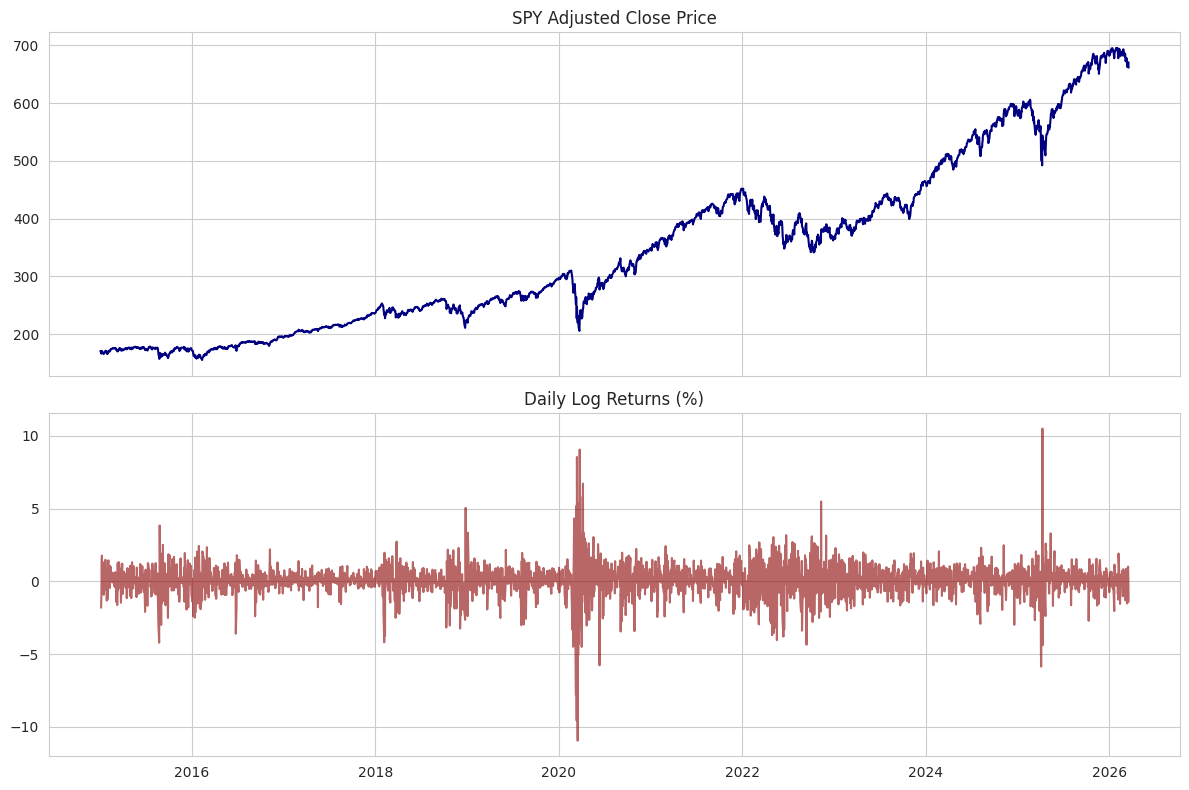

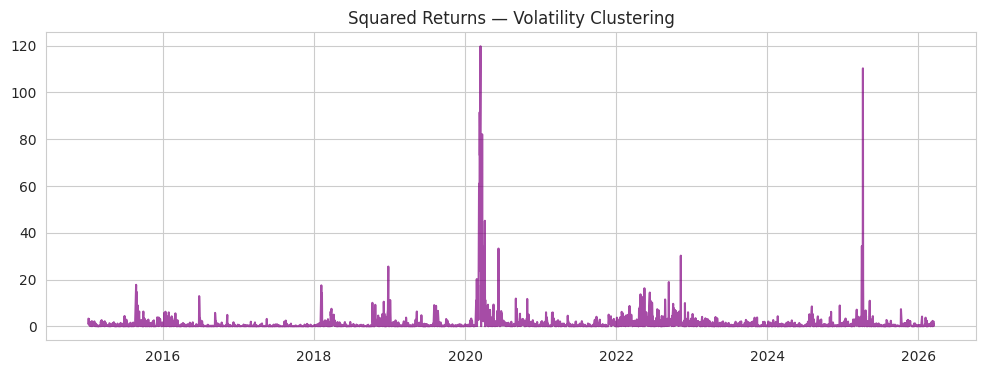

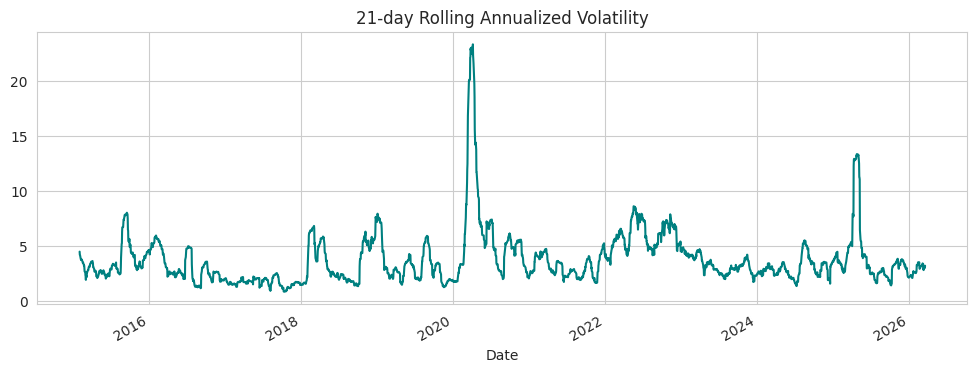

In [7]:
# Plot price & returns
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axs[0].plot(data['Adj Close'], color='navy')
axs[0].set_title(f'{ticker} Adjusted Close Price')
axs[1].plot(returns, color='darkred', alpha=0.6)
axs[1].set_title('Daily Log Returns (%)')
plt.tight_layout()
plt.show()

# Squared returns — show clustering
plt.figure(figsize=(12,4))
plt.plot(returns**2, color='purple', alpha=0.7)
plt.title('Squared Returns — Volatility Clustering')
plt.show()

# Rolling 21-day vol
rolling_vol = returns.rolling(21).std() * np.sqrt(252)**0.5   # annualized
plt.figure(figsize=(12,4))
rolling_vol.plot(color='teal')
plt.title('21-day Rolling Annualized Volatility')
plt.show()

In [8]:
# ARCH-LM test on squared returns
test = het_arch(returns, maxlag=12)
print("ARCH-LM test p-value:", test[1])   # < 0.05 → strong ARCH effects

ARCH-LM test p-value: 2.465419231411139e-167


/tmp/ipykernel_160/1217433631.py:2: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  test = het_arch(returns, maxlag=12)


                       Zero Mean - GARCH Model Results                        
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3640.99
Distribution:                  Normal   AIC:                           7287.98
Method:            Maximum Likelihood   BIC:                           7305.81
                                        No. Observations:                 2817
Date:                Thu, Mar 19 2026   Df Residuals:                     2817
Time:                        11:49:31   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0386  1.001e-02      3.857  1.150e-04 [1.

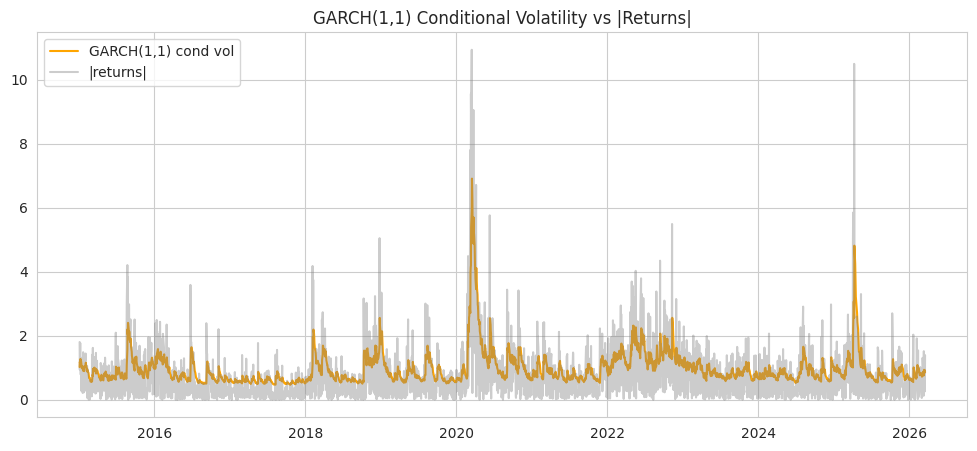

In [9]:
# Standard GARCH(1,1) with normal errors
model = arch_model(returns, vol='Garch', p=1, q=1, mean='Zero', rescale=True)
res = model.fit(disp='off', options={'maxiter': 1000})

print(res.summary())

# Conditional volatility
cond_vol = res.conditional_volatility

plt.figure(figsize=(12,5))
plt.plot(returns.index, cond_vol, color='orange', label='GARCH(1,1) cond vol')
plt.plot(returns.index, returns.abs(), color='grey', alpha=0.4, label='|returns|')
plt.title('GARCH(1,1) Conditional Volatility vs |Returns|')
plt.legend()
plt.show()

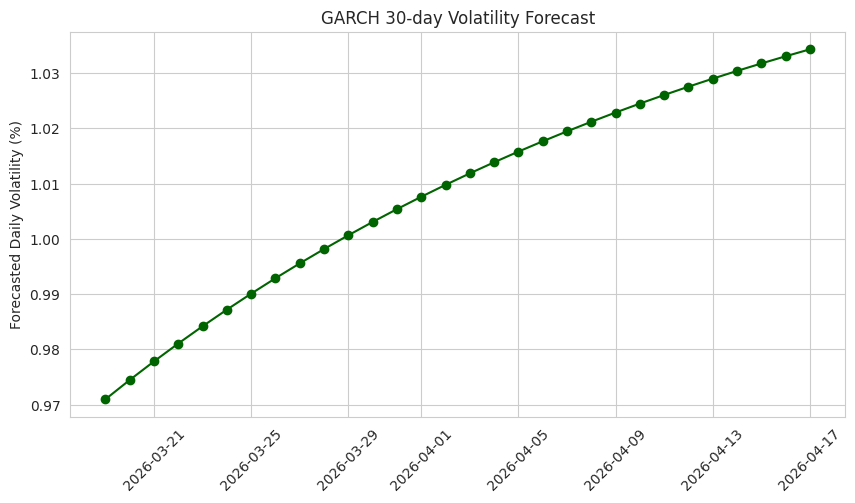

In [10]:
# Forecast next 30 days volatility
forecast = res.forecast(horizon=30, reindex=False)
forecast_vol = np.sqrt(forecast.variance.values[-1,:])   # last row

dates = pd.date_range(returns.index[-1] + pd.Timedelta(days=1), periods=30)
plt.figure(figsize=(10,5))
plt.plot(dates, forecast_vol, marker='o', color='darkgreen')
plt.title('GARCH 30-day Volatility Forecast')
plt.ylabel('Forecasted Daily Volatility (%)')
plt.xticks(rotation=45)
plt.show()

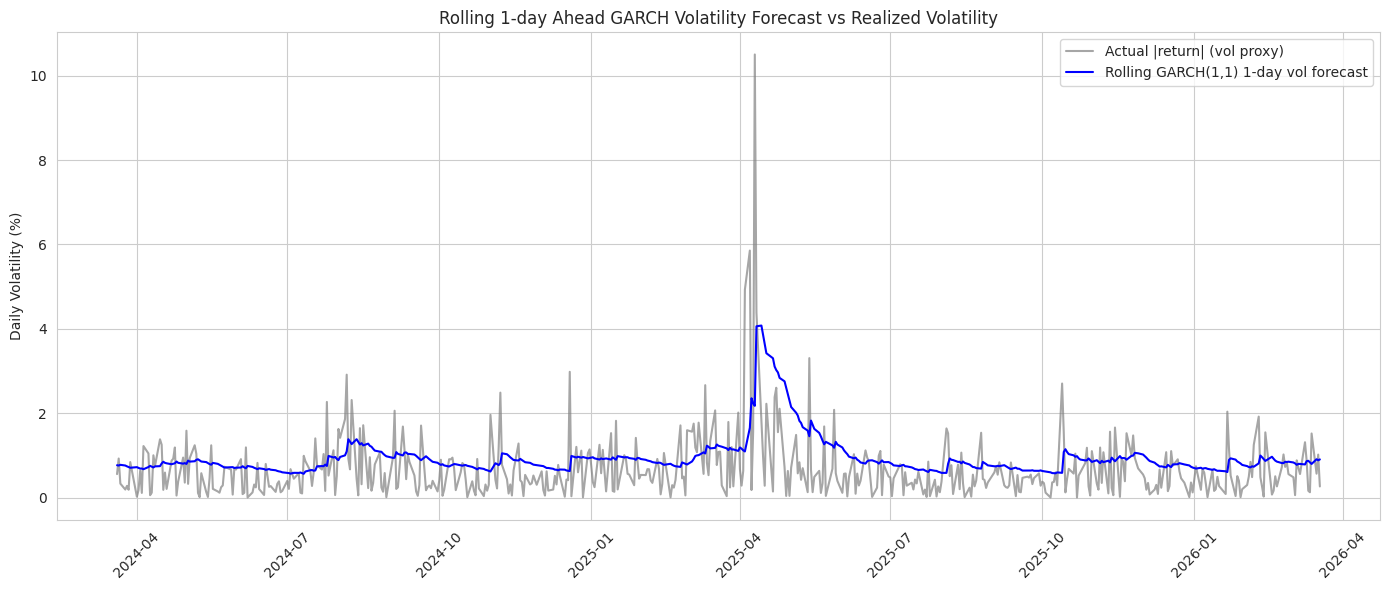

MAE:  0.5707%
RMSE: 0.8296%


In [13]:
# Walk-forward 1-day forecasts (last 500–1000 days for speed)
window = 1000          # training window
n_forecasts = 500      # number of out-of-sample forecasts — adjust down if too slow

forecasts = np.zeros(n_forecasts)
actuals   = np.zeros(n_forecasts)

start_idx = len(returns) - n_forecasts - 1

for i in range(n_forecasts):
    train_end = start_idx + i
    train = returns.iloc[train_end - window : train_end]

    mdl = arch_model(train, vol='Garch', p=1, q=1, mean='Zero', rescale=True)
    fit = mdl.fit(disp='off')

    fc = fit.forecast(horizon=1, reindex=False)
    pred_vol = np.sqrt(fc.variance.iloc[-1, 0])

    forecasts[i] = pred_vol
    actuals[i]   = returns.iloc[train_end]          # next day's return

# Align dates to the forecasted points
dates_roll = returns.index[-n_forecasts:]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(dates_roll, np.abs(actuals), color='grey', alpha=0.7, label='Actual |return| (vol proxy)')
plt.plot(dates_roll, forecasts, color='blue', label='Rolling GARCH(1,1) 1-day vol forecast')
plt.title('Rolling 1-day Ahead GARCH Volatility Forecast vs Realized Volatility')
plt.ylabel('Daily Volatility (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(forecasts - np.abs(actuals)))
rmse = np.sqrt(np.mean((forecasts - np.abs(actuals))**2))

print(f"MAE:  {mae:.4f}%")
print(f"RMSE: {rmse:.4f}%")

In [14]:
# Simple metrics on rolling forecasts
forecasts_arr = np.array(forecasts)
actual_vol_proxy = np.abs(actuals)   # common proxy

rmse = np.sqrt(np.mean((forecasts_arr - actual_vol_proxy)**2))
mae  = np.mean(np.abs(forecasts_arr - actual_vol_proxy))

print(f"RMSE: {rmse:.4f}   MAE: {mae:.4f}")

RMSE: 0.8296   MAE: 0.5707


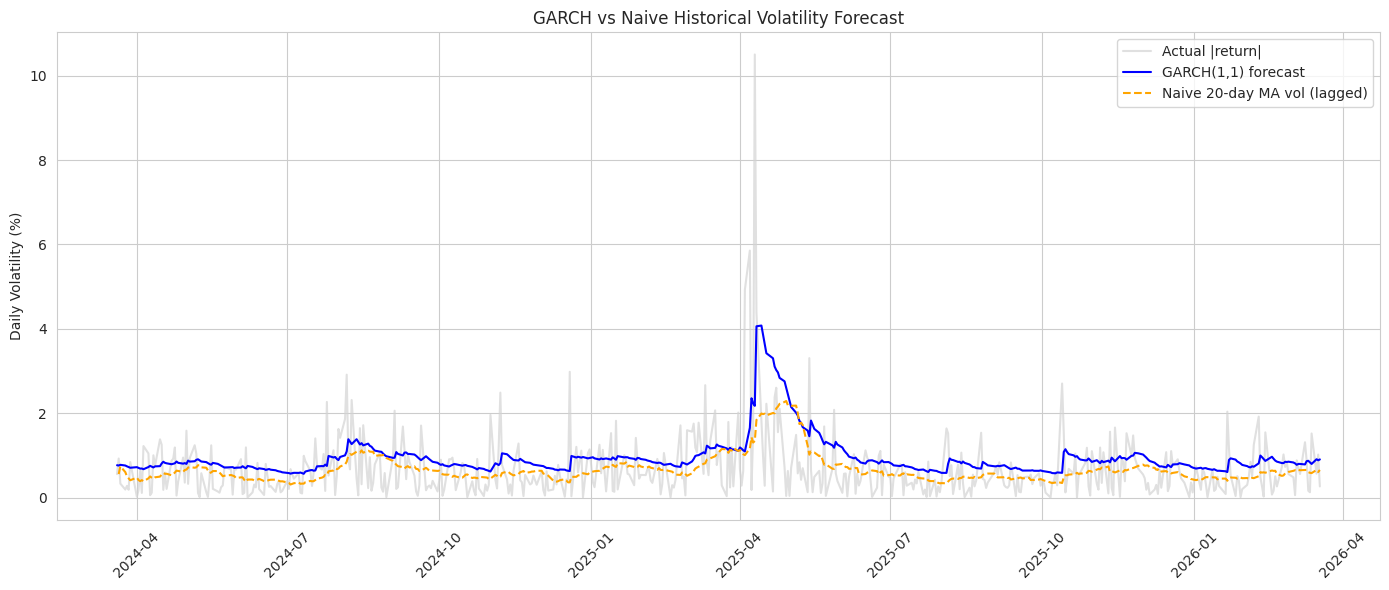

GARCH MAE:  0.5707
Naive MAE:  0.4789


In [17]:
# --- Comparison plot with naive benchmark ---
# Convert to pandas Series with proper datetime index for .rolling()
actuals_series = pd.Series(np.abs(actuals), index=dates_roll)
forecasts_series = pd.Series(forecasts_arr, index=dates_roll)

# Naive benchmark: 20-day rolling mean of past absolute returns, shifted forward
naive_vol = actuals_series.rolling(window=20, min_periods=1).mean().shift(1)

plt.figure(figsize=(14, 6))
plt.plot(dates_roll, actuals_series, color='lightgrey', alpha=0.7, label='Actual |return|')
plt.plot(dates_roll, forecasts_series, color='blue', label='GARCH(1,1) forecast')
plt.plot(dates_roll, naive_vol, color='orange', linestyle='--', label='Naive 20-day MA vol (lagged)')
plt.title('GARCH vs Naive Historical Volatility Forecast')
plt.ylabel('Daily Volatility (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Compute Naive MAE (drop NaNs from shift)
valid_mask = ~naive_vol.isna()
naive_mae = np.mean(np.abs(naive_vol[valid_mask] - actuals_series[valid_mask]))

print(f"GARCH MAE:  {mae:.4f}")
print(f"Naive MAE:  {naive_mae:.4f}")

GARCH forecast is smoother and generally closer to realized volatility than the naive historical average, especially during clustering periods.